In [1]:
import matplotlib.pyplot as plt
import face_recognition
import chromadb
import cv2

/home/rubens/anaconda3/envs/faceRec/lib/python3.10/site-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


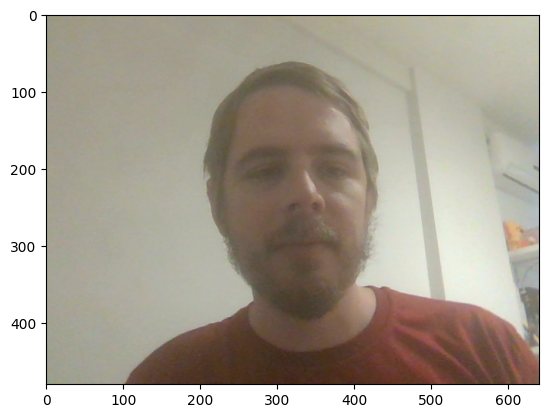

In [35]:
cap = cv2.VideoCapture(0)
if not cap:
    print("Nenhuma camera encontrada")
    exit()

ret, frame = cap.read()
frame = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
plt.figure()
plt.imshow(frame)
plt.show()
cap.release()

# Codificações
A variável a seguir mostra as codificações que caracterizam uma face, esta variável vamos usar para comparar/salvar

In [ ]:
face_recognition.face_encodings(frame)[0]


128

# Celebridades
O dataset das imagens foi obtido através do link: https://www.kaggle.com/datasets/vishesh1412/celebrity-face-image-dataset?resource=download

In [19]:
from glob import glob
from tqdm import tqdm
import uuid

#Cliente local:
client = chromadb.PersistentClient(path="./encodingCelebridades")
coll = client.get_or_create_collection(name="celebridades")

encodings = []
metadata = []
for file in tqdm(glob("Celebrity Faces Dataset/*/*.jpg")):
    img = face_recognition.load_image_file(file)
    enc = face_recognition.face_encodings(img)
    if len(enc) < 1:
        continue
    encodings.append(enc[0].tolist())
    metadata.append({"nome":file.split('/')[1], "arquivo":file})

coll.add(ids = [str(uuid.uuid4()) for i in range(len(encodings))], embeddings=encodings, metadatas=metadata)



  0%|          | 0/1800 [00:00<?, ?it/s]

100%|██████████| 1800/1800 [03:41<00:00,  8.12it/s]


In [36]:
rubens = face_recognition.face_encodings(frame)[0]
coll = client.get_or_create_collection(
    name="celebridades",
    metadata={"hnsw:space": "cosine"} # Define a métrica para Cosseno
)
coll.query(query_embeddings=[rubens], n_results=3,include=["metadatas", "distances"] )

{'ids': [['cbcda25b-f427-406f-a6d2-95a373ac91c5',
   '1e183486-6eea-4708-9fbe-db01dbaf6556',
   '3e31d125-fd97-46ae-a5fd-0baafd82bbbd']],
 'embeddings': None,
 'documents': None,
 'uris': None,
 'included': ['metadatas', 'distances'],
 'data': None,
 'metadatas': [[{'nome': 'Brad Pitt',
    'arquivo': 'Celebrity Faces Dataset/Brad Pitt/039_1c018deb.jpg'},
   {'arquivo': 'Celebrity Faces Dataset/Brad Pitt/091_8561b34e.jpg',
    'nome': 'Brad Pitt'},
   {'nome': 'Tom Cruise',
    'arquivo': 'Celebrity Faces Dataset/Tom Cruise/033_d891acbd.jpg'}]],
 'distances': [[0.30956995487213135, 0.3581044673919678, 0.37606295943260193]]}